# FWI · boundary compression robustness

`storage_dtype` shrinks the saved boundary wavefield (fp16/bf16 → 2 bytes/cell,
int8 → ~1 byte + a per-256-cell FP32 scale, ~3.9×) while **compute stays FP32** —
only the boundary *storage* is lossy.  This page confirms that the lossy storage
does **not** degrade a real inversion: the same Marmousi FWI is run under the full
`{gpu, cpu, disk} × {fp16, bf16, int8}` matrix (plus a `gpu·fp32` anchor) and the
loss curve, model-RMSE curve, and final inverted model are compared.

The *memory footprint* side (how much each combination actually saves, and where)
is covered in [Memory strategies](07_memory_strategies.ipynb); here the focus is
gradient/inversion **quality**.

## 1. Setup — Marmousi (25 m, 4 s) + observed data

In [1]:
import tempfile
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh, dt, nt = MARMOUSI_DH * 2, 0.002, 2000
freq, delay = 5.0, 0.20
nshots, nrec, batch_shots = 20, 200, 8
src_z, rec_z = 2, 4
lr, n_iter = 25.0, 30
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vp_true_np = load_marmousi('true')[::2, ::2].copy()
vp_init_np = load_marmousi('smooth')[::2, ::2].copy()
shape = vp_true_np.shape
src_x = np.linspace(shape[1] * 0.1, shape[1] * 0.9, nshots).astype(np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)
sources = np.stack([src_x, np.full(nshots, src_z, dtype=np.int64)], 1)
receivers = np.repeat(np.stack([rec_x, np.full(nrec, rec_z, dtype=np.int64)], 1)[None], nshots, 0)

# observed data: generated once in FP32 and shared by every config.
with torch.no_grad():
    solver_obs = PropTorch(Acoustic(device=device), shape=shape, dh=dh, dt=dt, nt=nt, impl='c')
    observed = solver_obs(wavelet, sources, receivers, models=[torch.tensor(vp_true_np, device=device)]).detach()
del solver_obs; torch.cuda.empty_cache()
print('device:', device, ' shape:', shape, ' observed:', tuple(observed.shape))

device: cuda  shape: (141, 681)  observed: (20, 2000, 200, 1)


## 2. Storage × dtype matrix · stochastic Adam FWI

Each config gets a fresh `PropTorch` with the chosen boundary `storage`/`storage_dtype`,
inverts the smooth start with Adam (`lr=25`, `eps=1e-16`), and replays the **same**
random shot-batch sequence (`default_rng(0)`) so the only difference between runs is
how the boundary is stored for the gradient reconstruction.

In [2]:
disk_dir = tempfile.mkdtemp(prefix='fwi_bdy_dtype_')

def mem_cfg(storage, dtype):
    b = {'storage': storage, 'storage_dtype': dtype}
    if storage in ('cpu', 'disk'):
        b['transfer_interval'] = 8
    if storage == 'cpu':
        b['pinned_memory'] = True
    if storage == 'disk':
        b['disk_dir'] = disk_dir
    return {'strategy': 'boundary', 'boundary': b}

configs = [('gpu', 'fp32')] + [(s, d) for s in ('gpu', 'cpu', 'disk') for d in ('fp16', 'bf16', 'int8')]
rmse = lambda a: float(np.sqrt(np.mean((a - vp_true_np) ** 2)))

results = {}
for storage, dtype in configs:
    label = f'{storage}·{dtype}'
    solver = PropTorch(Acoustic(device=device), shape=shape, dh=dh, dt=dt, nt=nt,
                       impl='c', memory=mem_cfg(storage, dtype))
    vp = torch.tensor(vp_init_np, device=device, requires_grad=True)
    opt = torch.optim.Adam([vp], lr=lr, eps=1e-16)
    rng = np.random.default_rng(0)
    losses, rmses = [], [rmse(vp_init_np)]
    for _ in range(n_iter):
        idx = rng.choice(nshots, batch_shots, replace=False)
        opt.zero_grad()
        loss = (solver(wavelet, sources[idx], receivers[idx], models=[vp]) - observed[idx]).pow(2).mean()
        loss.backward(); opt.step()
        losses.append(float(loss.detach().cpu()))
        rmses.append(rmse(vp.detach().cpu().numpy()))
    results[label] = dict(storage=storage, dtype=dtype, losses=losses, rmses=rmses, vp=vp.detach().cpu().numpy())
    print(f"{label:10s} loss {losses[0]:.3e} -> {losses[-1]:.3e}   rmse {rmses[0]:.1f} -> {rmses[-1]:.1f}")
    del solver, vp, opt; torch.cuda.empty_cache()

gpu·fp32   loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


gpu·fp16   loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


gpu·bf16   loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


gpu·int8   loss 5.443e-02 -> 3.123e-03   rmse 357.3 -> 306.8


cpu·fp16   loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


cpu·bf16   loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


cpu·int8   loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


disk·fp16  loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


disk·bf16  loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


disk·int8  loss 5.443e-02 -> 3.122e-03   rmse 357.3 -> 306.8


## 3. Convergence — loss & model RMSE

Colour = dtype (fp32 black / fp16 blue / bf16 green / int8 red), line style =
storage (gpu solid / cpu dashed / disk dotted).  The curves land on top of each
other: lossy compression leaves the inversion trajectory unchanged.

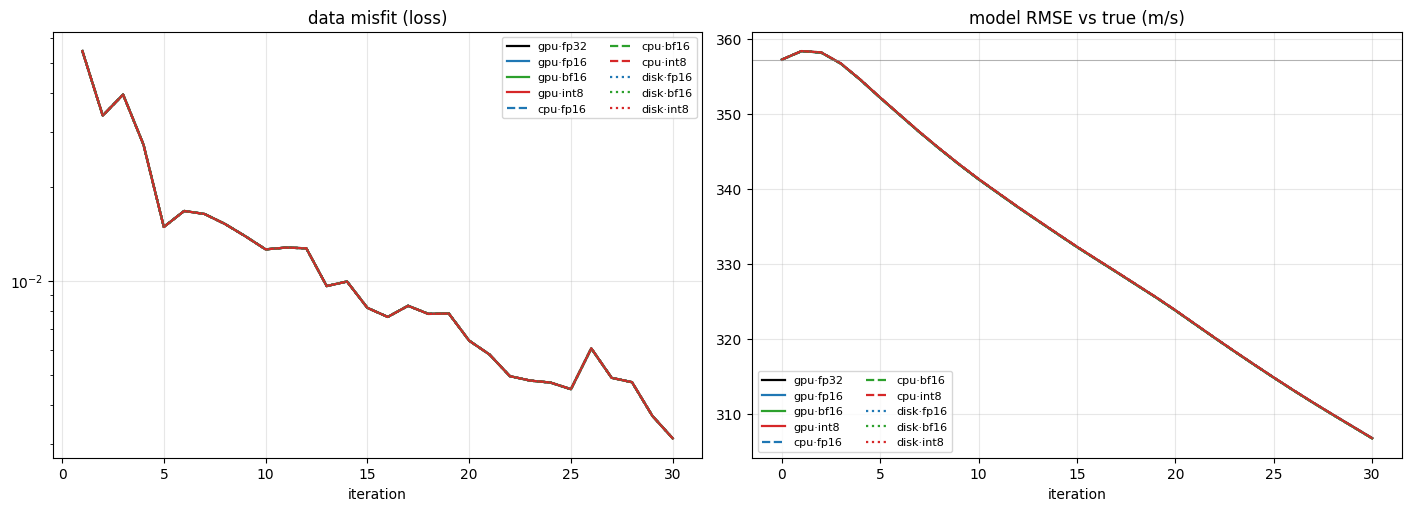

final loss / rmse per config:
  gpu·fp32   loss 3.122e-03   rmse 306.8
  gpu·fp16   loss 3.122e-03   rmse 306.8
  gpu·bf16   loss 3.122e-03   rmse 306.8
  gpu·int8   loss 3.123e-03   rmse 306.8
  cpu·fp16   loss 3.122e-03   rmse 306.8
  cpu·bf16   loss 3.122e-03   rmse 306.8
  cpu·int8   loss 3.122e-03   rmse 306.8
  disk·fp16  loss 3.122e-03   rmse 306.8
  disk·bf16  loss 3.122e-03   rmse 306.8
  disk·int8  loss 3.122e-03   rmse 306.8


In [3]:
col = {'fp32': 'k', 'fp16': 'tab:blue', 'bf16': 'tab:green', 'int8': 'tab:red'}
ls = {'gpu': '-', 'cpu': '--', 'disk': ':'}
rmse0 = float(np.sqrt(np.mean((vp_init_np - vp_true_np) ** 2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for lbl, v in results.items():
    axes[0].plot(range(1, len(v['losses']) + 1), v['losses'], color=col[v['dtype']], ls=ls[v['storage']], label=lbl, lw=1.6)
    axes[1].plot(range(len(v['rmses'])), v['rmses'], color=col[v['dtype']], ls=ls[v['storage']], label=lbl, lw=1.6)
axes[0].set_yscale('log'); axes[0].set_title('data misfit (loss)'); axes[0].set_xlabel('iteration'); axes[0].grid(alpha=0.3)
axes[1].set_title('model RMSE vs true (m/s)'); axes[1].set_xlabel('iteration'); axes[1].grid(alpha=0.3)
axes[1].axhline(rmse0, color='gray', lw=0.8, alpha=0.6)
axes[0].legend(fontsize=8, ncol=2); axes[1].legend(fontsize=8, ncol=2)
plt.show()
print('final loss / rmse per config:')
for lbl, v in results.items():
    print(f"  {lbl:10s} loss {v['losses'][-1]:.3e}   rmse {v['rmses'][-1]:.1f}")

## 4. Final inverted models

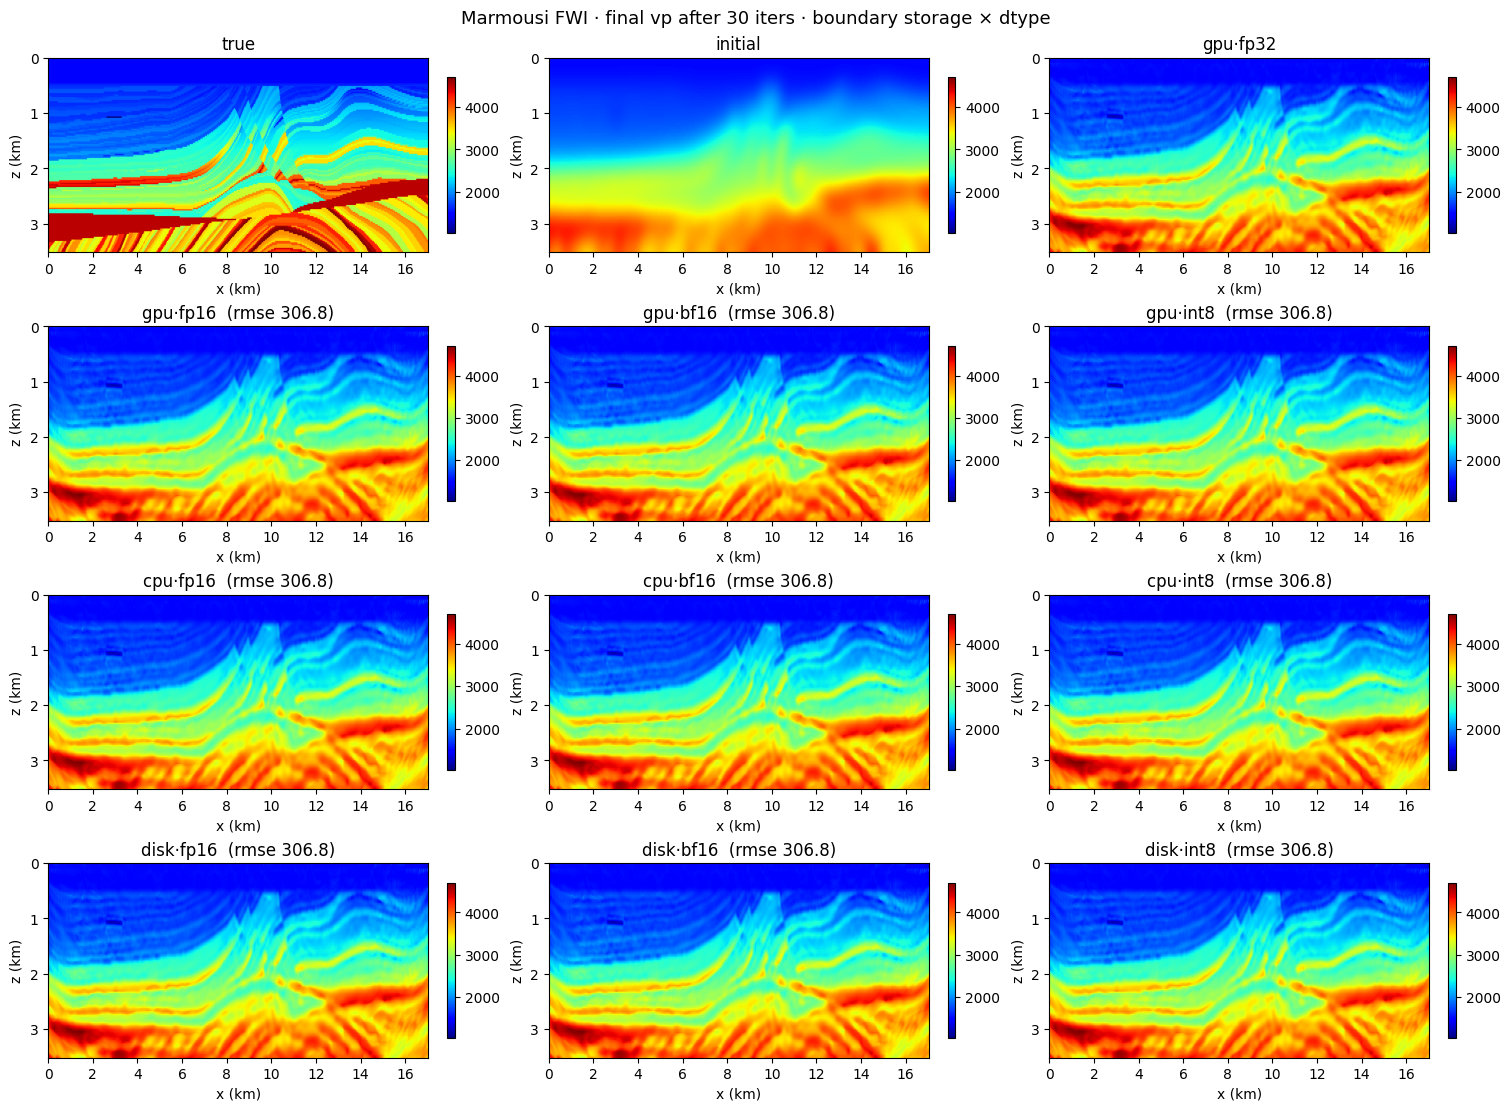

In [4]:
vmin, vmax = float(vp_true_np.min()), float(vp_true_np.max())
ext = [0, shape[1]*dh/1000, shape[0]*dh/1000, 0]
fig, axes = plt.subplots(4, 3, figsize=(15, 11), constrained_layout=True)
for ax, (ttl, m) in zip(axes[0], [('true', vp_true_np), ('initial', vp_init_np), ('gpu·fp32', results['gpu·fp32']['vp'])]):
    im = ax.imshow(m, cmap='jet', vmin=vmin, vmax=vmax, aspect='auto', extent=ext)
    ax.set_title(ttl); ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)'); fig.colorbar(im, ax=ax, shrink=0.8)
for r, storage in enumerate(('gpu', 'cpu', 'disk')):
    for c, dtype in enumerate(('fp16', 'bf16', 'int8')):
        ax = axes[r+1][c]; lbl = f'{storage}·{dtype}'
        im = ax.imshow(results[lbl]['vp'], cmap='jet', vmin=vmin, vmax=vmax, aspect='auto', extent=ext)
        ax.set_title(f"{lbl}  (rmse {results[lbl]['rmses'][-1]:.1f})")
        ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)'); fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle(f'Marmousi FWI · final vp after {n_iter} iters · boundary storage × dtype', fontsize=13)
plt.show()

## Takeaway

All nine `{gpu, cpu, disk} × {fp16, bf16, int8}` combinations track the `gpu·fp32`
anchor: identical loss decay, identical model-RMSE convergence, and visually
indistinguishable final models.  Lossy boundary storage (down to int8's ~3.9×
compression) does not measurably harm acoustic FWI here — pick the storage by the
memory budget ([Memory strategies](07_memory_strategies.ipynb)) and the dtype by
how aggressively you need to shrink the boundary buffer.

---

**Download this notebook** &mdash; [`18_fwi_boundary_dtype.ipynb`](18_fwi_boundary_dtype.ipynb) &middot; or [view on GitHub](https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/18_fwi_boundary_dtype.ipynb)